# Hilfestellung zur Analyse der Messdaten zum Pohlschen Resonator

## Header

Zur Analyse von Daten werden unterschiedliche Pakete verwendet. Einige erleichtern das Rechnen, andere werden für das Anfitten von Modell-Funktionen oder zur Darstellung von Daten verwendet. Diese Pakete werden hier geladen und ihnen werden Abkürzungen zugeordnet, damit sie später leichter verwendet werden können:

In [156]:
import numpy as np
import matplotlib.pyplot as plt
import re

## Hilfsfunktionen zum Einlesen von Daten
Nutzen Sie die Funktion "Einlesen" unter Angabe eines Pfades zur Datei, die sie einlesen möchten.
Als Rückgabe erhalten Sie die Informationen zu Dämpfung (0), Antriebsfrequenz (1), Daten der Schwingung (2) und Nulldurchgänge des Antriebs (nur bei getriebenen Schwingungen) (3)

In [157]:
# Finde, in welcher Zeile bzw. welchen Zeilen '------' (in python: r'^\s*-{5,}\s*$') einen neuen Abschnitt markieren
def findCut(dateipfad,toFind=r'^\s*-{5,}\s*$',start=0):
    cut = None
    with open(dateipfad, "r", encoding="utf-8") as f:
        for skip in range(start):
            next(f)
        for i, line in enumerate(f):
            if re.match(toFind, line):
                cut = i
                break
    if cut is None:
        print('Die Dateistruktur entspricht nicht der Erwartung.')
    return cut

# Funktion liest aus der ersten Zeile der angegebenen Datei die Angaben zu Dämpfung (in mm) und antrieb (in mHz) aus
def Metadaten(dateipfad):
    file = open(dateipfad, 'r')
    firstline = file.readline().split()
    daempfung = float(firstline[firstline.index('mm,')-1] )       # Einheit: mm
    antrieb = float(firstline[firstline.index('mHz')-1] )         # Einheit: mHz
    return daempfung, antrieb

# Rahmenfunktion, die Daten aus einem gegebenen Dateipfad einliest und 
# Dämpfung, Antrieb, Datensatz für Schwingung und Datensatz für Nulldurchgänge des Antriebs (falls getriebene Schwingung) ausgibt
def Einlesen(dateipfad, print_metadata=1):
    cut1 = findCut(dateipfad)
    daempfung, antrieb = Metadaten(dateipfad)
    if print_metadata:
        print('Messung mit Dämpfung %s und Antriebsfrequenz %s'%(daempfung, antrieb))
    if antrieb == 0:
        with open(dateipfad, 'r') as file:
            lines = file.readlines()
        zeit = []
        frequenz = []
        for i in range(cut1+2, len(lines)):
            line = lines[i].strip().split()
            zeit.append(float(line[0].replace(',','.')))
            frequenz.append(float(line[1].replace(',','.')))
        return daempfung, antrieb, np.array(zeit), np.array(frequenz)
    else:
        cut2 = findCut(dateipfad, start=cut1+1)
        zeit = []
        frequenz = []
        with open(dateipfad, 'r') as file:
            lines = file.readlines()
        for i in range(cut1+2, cut2+1):
            line = lines[i].strip().split()
            zeit.append(float(line[0].replace(',','.')))
            frequenz.append(float(line[1].replace(',','.')))
        nulldurchgaenge_antrieb = []
        for i in range(cut2+4, len(lines)):
            line = lines[i].strip().split()
            nulldurchgaenge_antrieb.append(float(line[0].replace(',','.')))
        return daempfung, antrieb, np.array(zeit), np.array(frequenz), np.array(nulldurchgaenge_antrieb)


Beispielanwedung zum Einlesen von Daten. Beachten Sie, dass Sie in der Variable 'ordner' ggf. den Verweis auf den entsprechenden Ordner ergänzen müssen, wenn der Code und die Daten in unterschiedlichen Ordnern gespeichert sind.

In [165]:
ordner = './'
dateipfad='Messung_2.txt'
data = Einlesen(ordner+dateipfad)

Messung mit Dämpfung 4.0 und Antriebsfrequenz 250.0


## Visualisierung der Daten
Übernehmen Sie dieses Schema im Folgenden, um einfach Abbildungen der Schwingungs-Messdaten zu erzeugen.

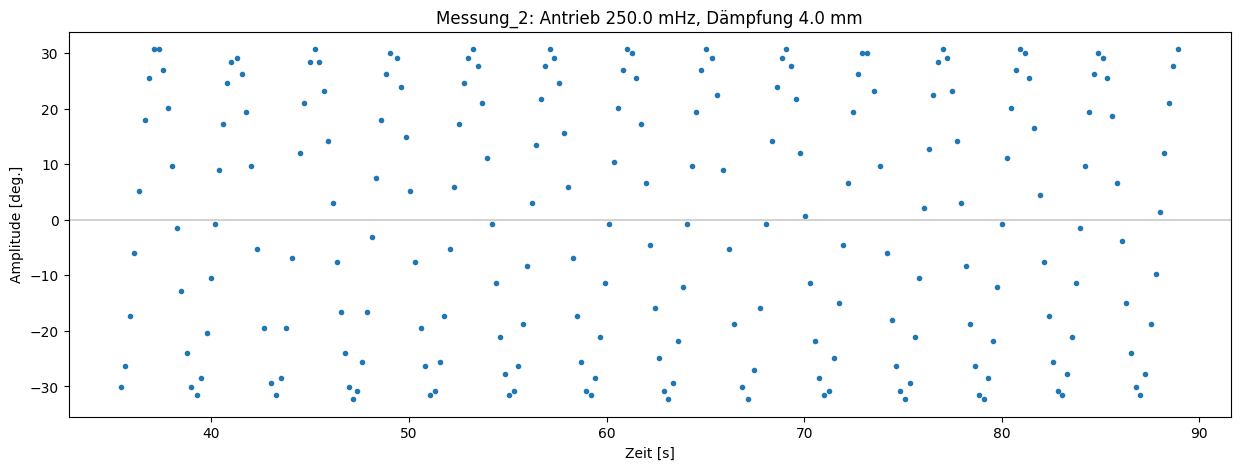

In [166]:
fig, ax = plt.subplots(figsize=(15,5))
# Beachte: data[2] enthält die Daten für die Zeit, data[3] enthält die Daten für den Auslenkwinkel
ax.plot(data[2],data[3],'.')
ax.set_xlabel('Zeit [s]')
ax.set_ylabel('Amplitude [deg.]')
ax.set_title('%s: Antrieb %s mHz, Dämpfung %s mm'%(dateipfad.split('.')[0],data[1],data[0]))
ax.axhline(0,color='lightgray')

## Hilfsfunktionen für die Auswertung

In [167]:
# Funktion zum Finden lokaler Maxima -- Es werden die Zeiten und Amplituden der lokalen Maxima ausgegeben
# Als Argument, das auf Maxima untersucht werden soll, ist hierbei zunächst die Amplitude (arg=1) angegeben,
# Sie können diese Funktion aber auch auf andere Argumente anwenden, wenn Sie die Variable arg ändern

def findLocalMaxima(zeiten, amplituden, arg=1):
    dataset = np.array([zeiten, amplituden]).transpose()
    mask = np.where((dataset[:-2, arg] <= dataset[1:-1, arg]) & (dataset[1:-1, arg] >= dataset[2:, arg]))[0]
    mask_filtered = np.delete(mask, np.where(np.diff(mask) == 1)[0] + 1)
    local_maxima = dataset[1:-1, :]
    local_maxima = local_maxima[mask_filtered]
    return local_maxima

def findLocalMinima(zeiten, amplituden, arg=1):
    dataset = np.array([zeiten, amplituden]).transpose()
    mask = np.where((dataset[:-2, arg] >= dataset[1:-1, arg]) & (dataset[1:-1, arg] <= dataset[2:, arg]))[0]
    mask_filtered = np.delete(mask, np.where(np.diff(mask) == 1)[0] + 1)
    local_minima = dataset[1:-1, :]
    local_minima = local_minima[mask_filtered]
    return local_minima

def findLocalExtreme(zeiten, amplituden, arg=1):
    dataset = np.array([zeiten, amplituden]).transpose()
    mask_max = np.where((dataset[:-2, arg] <= dataset[1:-1, arg]) & (dataset[1:-1, arg] >= dataset[2:, arg]))[0]
    mask_min = np.where((dataset[:-2, arg] >= dataset[1:-1, arg]) & (dataset[1:-1, arg] <= dataset[2:, arg]))[0]
    mask_max_filtered = np.delete(mask_max, np.where(np.diff(mask_max) == 1)[0] + 1)
    mask_min_filtered = np.delete(mask_min, np.where(np.diff(mask_min) == 1)[0] + 1)
    local_extreme = dataset[1:-1, :]
    local_extreme = np.concatenate((dataset[1:-1, :][mask_max_filtered], dataset[1:-1, :][mask_min_filtered]))
    return local_extreme


## Ungetriebene gedämpfte Schwingungen analysieren

### Vorbereitung/Vorselektion der Daten

Zunächst ist es ratsam die Daten vorzusortieren, die Sie analysieren möchten. Im folgenden sollen Sie (gedämpfte und ungedämpfte) Eigenschwingfrequenzen, logarithmische Dekremente und Dämpfungskoeffizienten bestimmen. Es gibt unterschiedliche Wege dies zu tun.<br>
Selektieren Sie in diesem Abschnitt zunächst, welche Daten Sie für die Analyse verwenden möchten.<br>
Lesen Sie hierfür die relevanten Dateien ein, verwenden Sie hierfür die Hilfsfunktion "Einlesen" und beispielsweise die Syntax:<br><br>
data1 = Einlesen(#hier Dateipfad zur ersten relevanten Messung einfügen)<br><br>
Beachten Sie, dass diese Daten nun unterschiedliche Dinge beinhalten:<br>
data1[0]: Dämpfung [mm]<br>
data1[1]: Antriebsfrequenz [mHz]<br>
data1[2]: Messdaten für Zeit [s] <br>
data1[3]: Messdaten für Auslenkungsamplitude [deg]<br>

Erstellen Sie dann reduzierte Datensätze, die Sie für die Auswertung verwenden möchten, verwenden Sie hierfür eine der Hilfsfunktionen zum Auffinden lokaler Maxima/ Minima/ Extrema.<br>
Beispielsweise:<br>
data1_max = findLocalMaxima(data1[2],data1[3])<br>

Achten Sie auf eine nachvollziehbare Benennung Ihrer Daten, verwenden Sie beispielsweise data_undamped_4, um anzuzeigen, dass es sich bei den Daten um Daten einer ungedämpften Schwingung mit einer Einstellung der Wirbelstrombremse bei 4mm handelt.

In [ ]:
# Lesen Sie hier relevante Daten ein:


# Sortieren Sie nun die entsprechenden Daten vor:


### Auswertung der gedämpften Eigenschwingfrequenz $\omega_e$

Wie hängt die Eigenschwingfrequenz mit den gemessenen Messwerten zusammen?<br>

Hinweise zu numpy-Funktionen:<br>
Die Differenz zwischen aufeinander folgenden Einträgen erhalten Sie über die Funktion np.diff(). <br>
Den Mittelwert von Daten erhalten Sie über np.mean()<br>
Die Standardabweichung von Daten erhalten Sie über np.std()<br><br>

Beachten Sie die Einheiten!

In [151]:
# Fügen Sie hier den entsprechenden Code ein:


### Auswertung des logarithmischen Dekrements $\Lambda$

Das logarithmische Dekrement ist über das Verhältnis von aufeinanderfolgenden Amplituden zur gleichen Phase innerhalb einer Schwingung definiert. Wählen Sie eine geeignete Reduktion Ihrer Daten aus, die Sie hierfür verwenden.<br><br>

Hinweis zu numpy-Funktionen:<br>
Das Verhältnis aufeinanderfolgender Einträge erhalten Sie beispielsweise mit der Funktion div: np.divide(a,np.roll(a,-1))<br>
Mit np.divide(a,b) führen Sie hierbei die Operation a/b durch,<br>
mit np.roll(a,-1) führen Sie eine zyklische Vertauschung der Einträge durch.<br>
Beachten Sie, dass im letzten Eintrag des neuen Array der letzte Eintrag von a durch den ersten Eintrag von a geteilt wird. Dieser Wert sollte daher nicht mit berücksichtigt werden.

In [152]:
# Berechnen Sie für Ihre unterschiedlichen Messreihen das logarithmische Dekrement

#log_Dekrement1 = np.divide( HIER NAMEN DES ARRAYS EINFUEGEN , np.roll( HIER NAMEN DES ARRAYS EINFUEGEN, -1))[:-1]

#print(log_Dekrement1.mean(),r'$\pm$',log_Dekrement1.std())

### Auswertung der Dämpfungskonstante $\beta$

Aus den Daten des logarithmischen Dekrements können Sie über weitere Messwerte die Dämpfungskonstante bestimmen. Alle wichtigen Funktionen hierfür haben Sie bereits genutzt.


In [153]:
# Bestimmung der Dämpfungskonstante für unterschiedliche Einstellungen der Wirbelstrombremse



### Bestimmung der Eigenschwingfrequenz $\omega_0$

Die Eigenschwingfrequenz ergibt sich aus vorherigen Ergebnissen zu gedämpften Eigenfrequenzen $\omega_e$ und Dämpfungskoeffizienten $\beta$.<br>
Versuchen Sie für Ihre Auswertung diesen Zusammenhang zunächst in eine Funktion zu überführen. Definieren Sie auch für die Fehlerberechnung eine Funktion zur Fehlerfortpflanzung.

Definiere eine Funktion, die den Zusammenhang zwischen omega_e und beta verwendet:

In [154]:
def eigenfrequenz(omega_e,beta):
    # Ergänzen Sie an dieser Stelle, wie sich aus omega_e und beta die eigenfrequenz ergibt
    result = 
    return result

def d_eigenfrequenz(omega_e,beta):
    # Ergänzen Sie an dieser Stelle, wie sich die Fehler von omega_e und beta auf das Ergebnis auswirken.
    # Nutzen Sie ggf. Zwischenergebnisse für die Auswirkungen des Fehlers von omega_e und beta (oder streichen Sie diese Zeilen aus dem Code)
    d_omegae = 
    d_beta = 
    result = 
    return result

SyntaxError: invalid syntax (2428811019.py, line 3)

### Überprüfung Ihrer Ergebnisse auf Konsistenz

Visualisieren Sie sich Ihre Ergebnisse, um zu überprüfen, ob sie konsistent mit Ihren Messungen sind. Visualisieren Sie hierfür die Messdaten und ergänzen jeweils ihr Ergebnis für die Einhüllende der gedämpften Schwingung.<br>
Definieren Sie hierfür zunächst, wie die Funktion der Einhüllenden aussehen sollte.<br>
Erstellen Sie dann für jede Messung einen Plot, in dem Sie die Messdaten und die Einhüllende darstellen.

In [ ]:
# Definiere zunächst eine Funktion für den Verlauf der Einhüllenden:
def einhuellende(time,beta):
    result = 
    return result

# Erstellen Sie sodann einen Plot:
# Erstellen Sie einen leeren Plot:
fig, ax = plt.subplots(figsize=(5,10))
# Fügen Sie die Messdaten in diesen Plot ein - ersetzen Sie die entsprechenden Referenzen auf ihre Daten:
ax.plot(Zeitdaten einfügen , Amplitudendaten einfügen,'.')

# Ergänzen Sie die Einhüllende über den selben Wertebereich, wie die Messung -- ersetzen Sie den entsprechenden Wert des Dämpfungskoeffizienten
ax.plot(Zeitdaten einfügen ,einhuellende(Zeitdaten einfügen, hier beta-Wert einfügen),color='gray')

ax.set_xlabel('Zeit [s]')
ax.set_ylabel('Amplitude [deg.]')

## Auswertung der getriebenen Schwingung

### Hilfsfunktionen zum Zusammenstellen der Daten aus unterschiedlichen Messungen

Diese Funktionen unterstützen dabei für unterschiedliche Messreihen die Daten der maximalen Amplitude und des Phasenversatzes zu berechnen.<br>
Die Funktion **FindPhase** ist hierbei eine Hilfsfunktion. Diese muss noch an wenigen Stelle **ergänzt** werden, damit Sie aus den bereits berechneten Daten der Phasenversatz berechnet wird.<br>

Die Funktion **DatenZusammenstellen** kann genutzt werden, um die relevanten Daten mehrerer Messreihen zusammenzustellen.<br> 
Übergeben Sie hierbei der Funktion die entsprechenenden Nummern der einzelnen Messungen als Liste (Bspw. DatenZusammenstellen([2,3]), wenn Sie die Messungen 'Messung_2.txt' und 'Messung_3.txt' auswerten wollen).


In [ ]:
# Hilfsfunktion, die hilft den Phasenunterschied zwischen der Anregung und der Systemantwort herauszufinden. Ergänzen Sie an entsprechenden Stellen, wie Sie vorgehen würden
def FindPhase(zeiten_schwingung, amplituden_schwingung, data_nulldurchgaenge,anregungsfrequenz):
    # Berechne die Periodenlänge aus den Angaben zur Anregungsfrequenz
    periodenlaenge = 1/anregungsfrequenz*1e3

    # Finde die Zeiten der lokalen Maxima der Schwingungen
    t_maxima_schwingung = findLocalMaxima(zeiten_schwingung,amplituden_schwingung)[:-1,0]

    # ERGÄNZUNG ERFORDERLICH!
    # Berechne aus den Angaben der Nulldurchgänge des Anregers und der Periodenlänge die zeitliche Position der Maxima der Anregung
    t_maxima_anregung = data_nulldurchgaenge[:-1] + 0.25*periodenlaenge

    # Verwerfe einzelne Datenpunkte, wenn die Arrays unterschiedlich viele Elemente enthalten
    if t_maxima_anregung.shape[0]<t_maxima_schwingung.shape[0]:
        print('Anzahl an Datenpunkten unterschiedlich, ich korrigiere dies. Überprüfe bitte, ob das sinnvoll ist!')
        t_maxima_schwingung = t_maxima_schwingung[:t_maxima_anregung.shape[0]]
        print('Gekürzte Daten:', t_maxima_anregung,t_maxima_schwingung)
    elif t_maxima_anregung.shape[0] > t_maxima_schwingung.shape[0]:
        print('Anzahl an Datenpunkten unterschiedlich, ich korrigiere dies. Überprüfe bitte, ob das sinnvoll ist!')
        t_maxima_anregung = t_maxima_anregung[:t_maxima_schwingung.shape[0]]
        print('Gekürzte Daten:', t_maxima_anregung,t_maxima_schwingung)

    diff_maxima = t_maxima_anregung- t_maxima_schwingung

    # ERGÄNZUNG ERFORDERLICH:
    # Berechne hier aus den zeitlichen Differenzen zwischen den Maximalposition bei Schwingung und Anregung die Phase zwischen den beiden Schwingungen
    phase =   # Phasendifferenz in Einheiten von pi

    return phase

def DatenZusammenstellen(ListeMessungen):
    # ERGÄNZE hier ggf. den Pfad zum Ordner, in dem die Messdaten gespeichert sind
    ordnerpfad = './'

    # Suche heraus, bei welcher Dämpfung die erste Messung durchgeführt wurde, um zu überprüfen, ob diese Angabe bei allen aufgelisteten Messungen gleich ist.
    daempfung = Einlesen(ordnerpfad+'Messung_'+str(ListeMessungen[0])+'.txt')[0]

    # Initialisiere Listen, in denen die Daten für 
    # Anregungsfrequenz, Amplitude, Messungenauigkeit angesichts der Unterschiede bei Mehrfachmessung, Phase und deren Messungenauigkeit gesammelt werden
    anregungsfrequenzen = []
    amplitude = []
    d_amplitude = []
    phase = []
    d_phase = []

    # Iteriere über die unterschiedlichen Messungen innerhalb der Messreihe
    for messung in ListeMessungen:
        # Einlesen der Daten:
        datei = ordnerpfad+'Messung_'+str(messung)+'.txt'
        data = Einlesen(datei)

        # Vergleich der Dämpfungsangaben bei den Messungen - Fehlermeldung, wenn unterschiedliche Dämpfungen verwendet wurden
        if data[0] != daempfung:
            print('Messung '+str(messung)+' ist bei einer anderen Dämpfung gemessen worden! Die Messungen sind so nicht vergleichbar.')

        # Ergänze die verwendete Anregungsfrequenz in dem entsprechenden Ordner
        anregungsfrequenzen.append(data[1])

        # Fügen Sie an dieser Stelle einen Wert für die Amplitude hinzu, beachten Sie, dass Sie den Code verändern müssen, wenn Sie die Einschwingphase ebenfalls in den Daten enthalten haben
        amplitude_i = findLocalMaxima(data[2],data[3])[:,1]
        amplitude.append( amplitude_i.mean() )
        d_amplitude.append( amplitude_i.std() )

        # Fügen Sie an dieser Stelle einen Wert für den Phasenversatz hinzu, beachten Sie, dass Sie den Code verändern müssen, wenn Sie die Einschwingphase ebenfalls in den Daten enthalten haben
        phase_i = FindPhase(data[2],data[3],data[4],data[1])
        if phase_i.mean()<0:
            phase_i += 2
        phase.append(phase_i.mean())
        d_phase.append(phase_i.std())

    print(amplitude, d_amplitude, phase, d_phase)



SyntaxError: invalid syntax (2999925688.py, line 27)

### Visualisierung der Ergebnisse

Nutzen Sie die zuvor definierten Funktionen, um im Folgenden die Daten der Messungen zu getriebenen Schwingungen darzustellen.

In [ ]:
# Fügen Sie hier den Code ein, der mithilfe der Funktion DatenZusammenstellen